<a href="https://colab.research.google.com/github/fablan-code/portfolio/blob/main/Trabajo_final_de_Integraci%C3%B3n_Facundo_Blanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

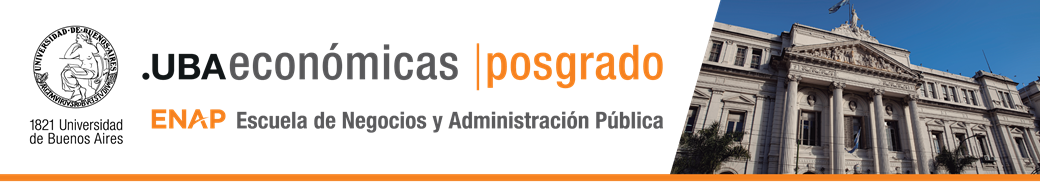

# <center>ESPECIALIZACIÓN EN MÉTODOS CUANTITATIVOS PARA LA GESTIÓN Y ANÁLISIS DE DATOS EN ORGANIZACIONES</center>
# <center> **TRABAJO FINAL INTEGRADOR** </center>
# <center> **2025** </center>

**ESTUDIANTE**

*   Blanco, Facundo Matías




# 1- librerias y dataframe

In [ ]:
# Librerias generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

#Modelos estadísticos
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.multivariate.manova import MANOVA
import scipy.stats as stats
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Clustering y distancias
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fcluster
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans


#Modelos de predicción
import sklearn as sk
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Base de datos desde csv
df = pd.read_csv("/content/enriched_employee_dataset.csv")

# 2- Exploración de los datos

In [ ]:
df.shape

(22750, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee ID              22750 non-null  object 
 1   Date of Joining          22750 non-null  object 
 2   Gender                   22750 non-null  object 
 3   Company Type             22750 non-null  object 
 4   WFH Setup Available      22750 non-null  object 
 5   Designation              22750 non-null  int64  
 6   Resource Allocation      21369 non-null  float64
 7   Mental Fatigue Score     20633 non-null  float64
 8   Burn Rate                21626 non-null  float64
 9   Years in Company         22750 non-null  int64  
 10  Work Hours per Week      22750 non-null  int64  
 11  Sleep Hours              22750 non-null  float64
 12  Work-Life Balance Score  22750 non-null  int64  
 13  Manager Support Score    22750 non-null  int64  
 14  Deadline Pressure Scor

In [ ]:
df.head(10)

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Years in Company,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16,16,35,7.5,3,3,1,16,2
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36,16,41,7.1,5,3,3,10,5
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49,16,53,5.7,2,3,5,17,0
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20,16,43,6.7,3,3,1,13,2
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52,16,51,5.2,1,3,4,18,0
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2,4.0,3.6,0.29,16,41,7.0,4,4,3,9,5
6,fffe33003300340039003100,2008-01-02,Female,Service,No,3,6.0,7.9,0.62,17,52,5.3,2,3,5,18,0
7,fffe32003600320037003400,2008-10-31,Female,Service,Yes,2,4.0,4.4,0.33,16,37,6.8,4,5,3,14,5
8,fffe32003200300034003700,2008-12-27,Female,Service,No,3,6.0,NaN,0.56,16,50,5.0,1,2,4,16,1
9,fffe31003600320030003200,2008-03-09,Female,Product,No,3,6.0,NaN,0.67,16,58,4.5,2,3,4,12,0


In [ ]:
#Cantidad de nulos por columna
null_counts = df.isnull().sum()
print("Cantidad de nulos por columna:")
print(null_counts)


Cantidad de nulos por columna:
Employee ID                   0
Date of Joining               0
Gender                        0
Company Type                  0
WFH Setup Available           0
Designation                   0
Resource Allocation        1381
Mental Fatigue Score       2117
Burn Rate                  1124
Years in Company              0
Work Hours per Week           0
Sleep Hours                   0
Work-Life Balance Score       0
Manager Support Score         0
Deadline Pressure Score       0
Team Size                     0
Recognition Frequency         0
dtype: int64


In [ ]:
null_perc = df.isnull().mean() * 100
print("\nPorcentaje de nulos por columna:")
print(null_perc.round(2))


Porcentaje de nulos por columna:
Employee ID                0.00
Date of Joining            0.00
Gender                     0.00
Company Type               0.00
WFH Setup Available        0.00
Designation                0.00
Resource Allocation        6.07
Mental Fatigue Score       9.31
Burn Rate                  4.94
Years in Company           0.00
Work Hours per Week        0.00
Sleep Hours                0.00
Work-Life Balance Score    0.00
Manager Support Score      0.00
Deadline Pressure Score    0.00
Team Size                  0.00
Recognition Frequency      0.00
dtype: float64


In [ ]:
# Columnas categoricas
cols_categ = df.select_dtypes(include=['object']).columns
cols_categ

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available'],
      dtype='object')

In [ ]:
# Columnas numericas
cols_numeric = df.select_dtypes(include=['int64', 'float64']).columns
cols_numeric

Index(['Designation', 'Resource Allocation', 'Mental Fatigue Score',
       'Burn Rate', 'Years in Company', 'Work Hours per Week', 'Sleep Hours',
       'Work-Life Balance Score', 'Manager Support Score',
       'Deadline Pressure Score', 'Team Size', 'Recognition Frequency'],
      dtype='object')

# 3- Preparación de los datos

In [ ]:
#copia para preparar los datos
df_prep = df.copy()

In [ ]:
#Retiro de nulos de la variable objetivo - Burn rate
df_prep = df.dropna(subset=['Burn Rate'])

In [ ]:
df_prep.shape

(21626, 17)

In [ ]:
#Retiro de nulos restantes
df_prep = df_prep.dropna()

In [ ]:
df_prep.shape

(18590, 17)

In [ ]:
#valores de Years in Company
df_prep["Years in Company"].unique()

array([16, 17])

In [ ]:
#Drop columna de fecha de ingreso a la compañía - No aporta valor analítico
df_prep = df_prep.drop(['Date of Joining', "Years in Company"], axis=1)

In [ ]:
#Drop EmployeeID
df_prep = df_prep.drop(['Employee ID'], axis=1)

In [ ]:
df_prep.shape

(18590, 14)

# 4- Análisis de las variables

## 4.1- Analisis de variables numéricas

In [ ]:
numeric_cols = ["Designation", "Resource Allocation", "Mental Fatigue Score",
    "Burn Rate", "Years in Company", "Work Hours per Week", "Sleep Hours",
    "Work-Life Balance Score", "Manager Support Score",
    "Deadline Pressure Score", "Team Size", "Recognition Frequency"]


###Designation

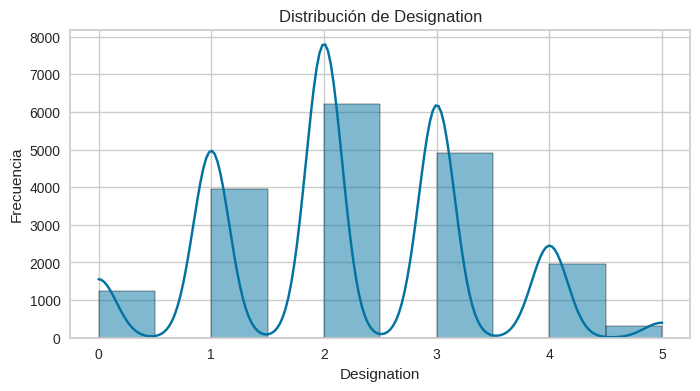

In [ ]:
#Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Designation"], kde=True, bins=10)
plt.title("Distribución de Designation")
plt.xlabel("Designation")
plt.ylabel("Frecuencia")
plt.show()

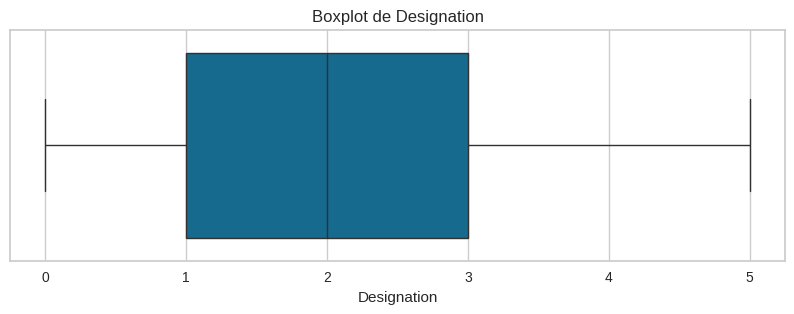

In [ ]:
#Boxplot
plt.figure(figsize=(10,3))
sns.boxplot(x=df_prep["Designation"])
plt.title("Boxplot de Designation")
plt.xlabel("Designation")
plt.show()

In [ ]:
#Estadística descriptiva
df_prep["Designation"].describe()

,Designation
count,18590.000000
mean,2.179398
std,1.133148
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


### Resource Allocation

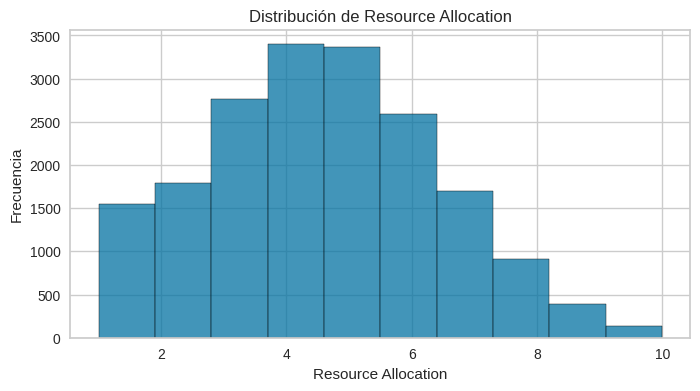

In [ ]:
#Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Resource Allocation"], bins=10)
plt.title("Distribución de Resource Allocation")
plt.xlabel("Resource Allocation")
plt.ylabel("Frecuencia")
plt.show()

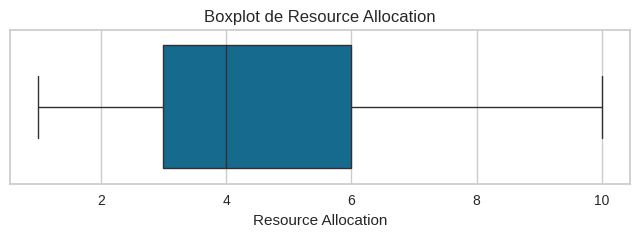

In [ ]:
#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Resource Allocation"])
plt.title("Boxplot de Resource Allocation")
plt.xlabel("Resource Allocation")
plt.show()

In [ ]:
#Estadística descriptiva
df_prep["Resource Allocation"].describe()

,Resource Allocation
count,18590.000000
mean,4.486552
std,2.044848
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,10.000000


###Mental Fatigue Score

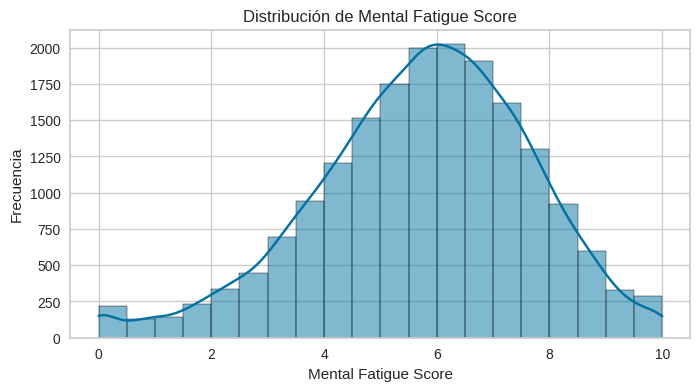

In [ ]:
#Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Mental Fatigue Score"], kde=True, bins=20)
plt.title("Distribución de Mental Fatigue Score")
plt.xlabel("Mental Fatigue Score")
plt.ylabel("Frecuencia")
plt.show()

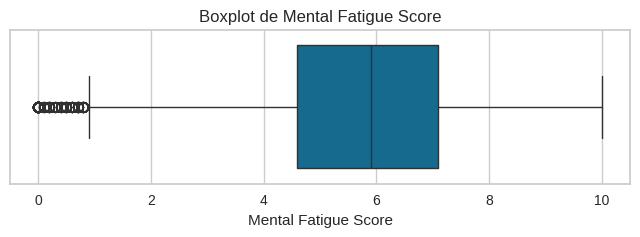

In [ ]:
#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Mental Fatigue Score"])
plt.title("Boxplot de Mental Fatigue Score")
plt.xlabel("Mental Fatigue Score")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Mental Fatigue Score"].describe()

,Mental Fatigue Score
count,18590.000000
mean,5.732173
std,1.920547
min,0.000000
25%,4.600000
50%,5.900000
75%,7.100000
max,10.000000


###Burn Rate

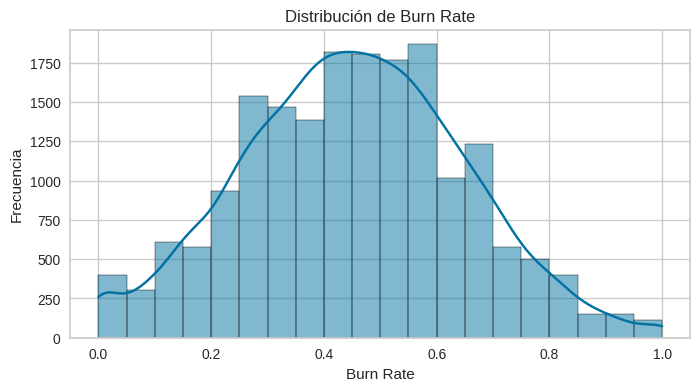

In [ ]:
#Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Burn Rate"], kde=True, bins=20)
plt.title("Distribución de Burn Rate")
plt.xlabel("Burn Rate")
plt.ylabel("Frecuencia")
plt.show()

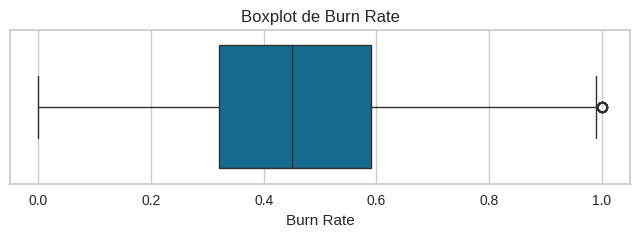

In [ ]:
#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Burn Rate"])
plt.title("Boxplot de Burn Rate")
plt.xlabel("Burn Rate")
plt.show()

In [ ]:
#Estadística descriptiva
df_prep["Burn Rate"].describe()

,Burn Rate
count,18590.000000
mean,0.452444
std,0.197848
min,0.000000
25%,0.320000
50%,0.450000
75%,0.590000
max,1.000000


### Work Hours per Week

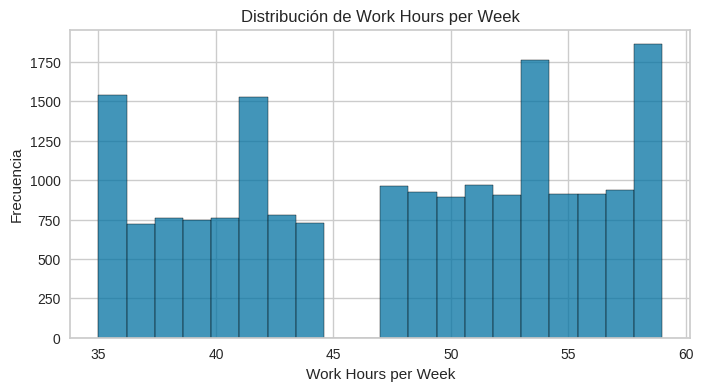

In [ ]:
#Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Work Hours per Week"], kde=False, bins=20)
plt.title("Distribución de Work Hours per Week")
plt.xlabel("Work Hours per Week")
plt.ylabel("Frecuencia")
plt.show()

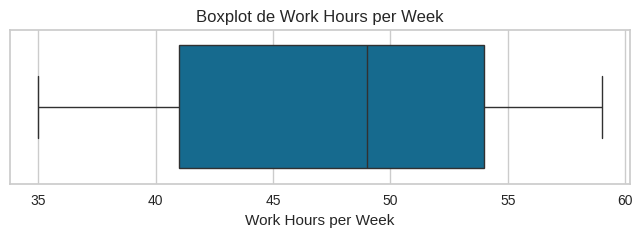

In [ ]:
#Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Work Hours per Week"])
plt.title("Boxplot de Work Hours per Week")
plt.xlabel("Work Hours per Week")
plt.show()

In [ ]:
#Estadistica descriptiva
df_prep["Work Hours per Week"].describe()

,Work Hours per Week
count,18590.000000
mean,47.801668
std,7.602354
min,35.000000
25%,41.000000
50%,49.000000
75%,54.000000
max,59.000000


### Sleep Hours

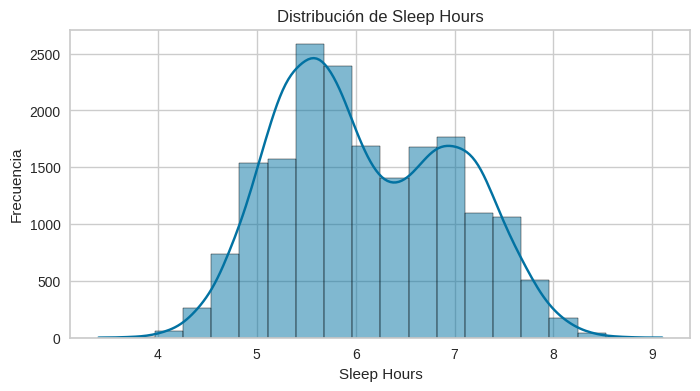

In [ ]:
# HISTOGRAMA: Sleep Hours

plt.figure(figsize=(8,4))
sns.histplot(df_prep["Sleep Hours"], kde=True, bins=20)
plt.title("Distribución de Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frecuencia")
plt.show()

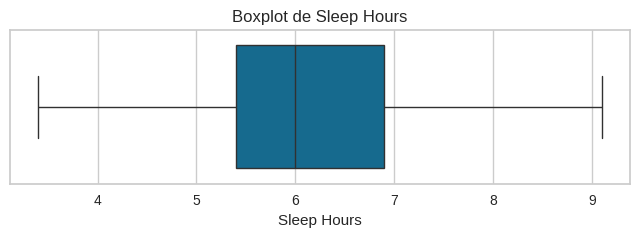

In [ ]:
# BOXPLOT: Sleep Hours
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Sleep Hours"])
plt.title("Boxplot de Sleep Hours")
plt.xlabel("Sleep Hours")
plt.show()

In [ ]:
# ESTADÍSTICA DESCRIPTIVA
df_prep["Sleep Hours"].describe()

,Sleep Hours
count,18590.000000
mean,6.110113
std,0.886955
min,3.400000
25%,5.400000
50%,6.000000
75%,6.900000
max,9.100000


### Work-Life Balance

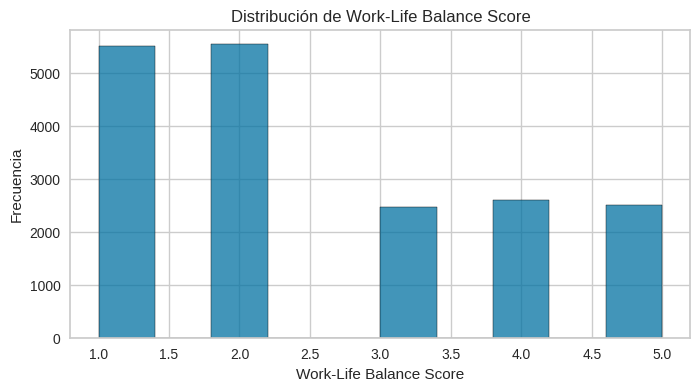

In [ ]:
# Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Work-Life Balance Score"], kde=False, bins=10)
plt.title("Distribución de Work-Life Balance Score")
plt.xlabel("Work-Life Balance Score")
plt.ylabel("Frecuencia")
plt.show()

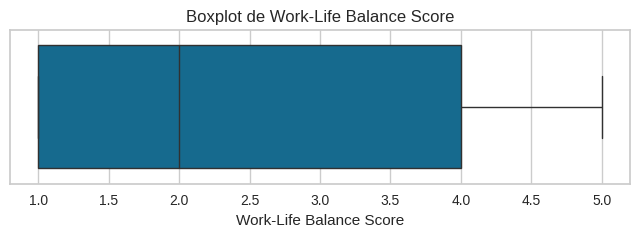

In [ ]:
# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Work-Life Balance Score"])
plt.title("Boxplot de Work-Life Balance Score")
plt.xlabel("Work-Life Balance Score")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Work-Life Balance Score"].describe()

,Work-Life Balance Score
count,18590.000000
mean,2.518666
std,1.387661
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,5.000000


### Manager Support Score

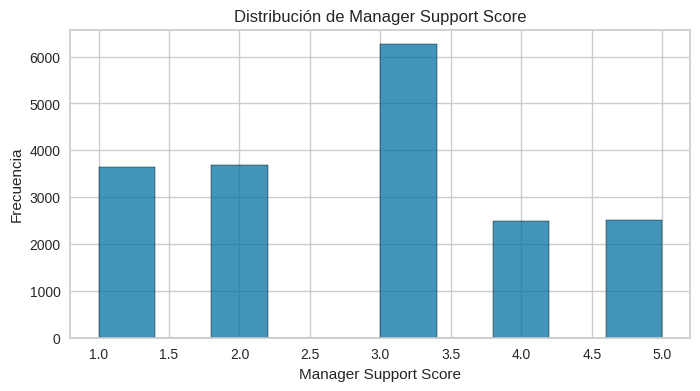

In [ ]:
# Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Manager Support Score"], kde=False, bins=10)
plt.title("Distribución de Manager Support Score")
plt.xlabel("Manager Support Score")
plt.ylabel("Frecuencia")
plt.show()

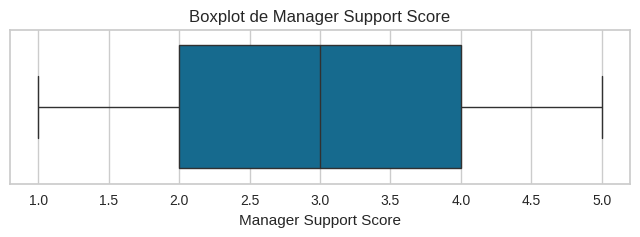

In [ ]:
# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Manager Support Score"])
plt.title("Boxplot de Manager Support Score")
plt.xlabel("Manager Support Score")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Manager Support Score"].describe()

,Manager Support Score
count,18590.000000
mean,2.812426
std,1.273780
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


### Deadline Pressure Score

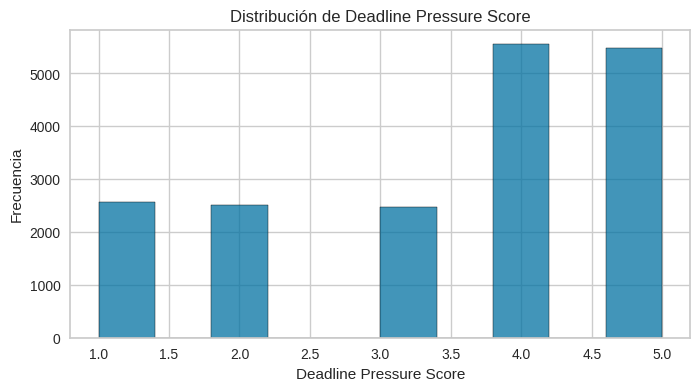

In [ ]:
# Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Deadline Pressure Score"], kde=False, bins=10)
plt.title("Distribución de Deadline Pressure Score")
plt.xlabel("Deadline Pressure Score")
plt.ylabel("Frecuencia")
plt.show()


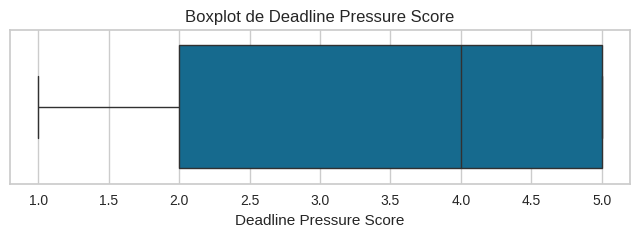

In [ ]:
# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Deadline Pressure Score"])
plt.title("Boxplot de Deadline Pressure Score")
plt.xlabel("Deadline Pressure Score")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Deadline Pressure Score"].describe()

,Deadline Pressure Score
count,18590.000000
mean,3.476869
std,1.392199
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,5.000000


###Team size

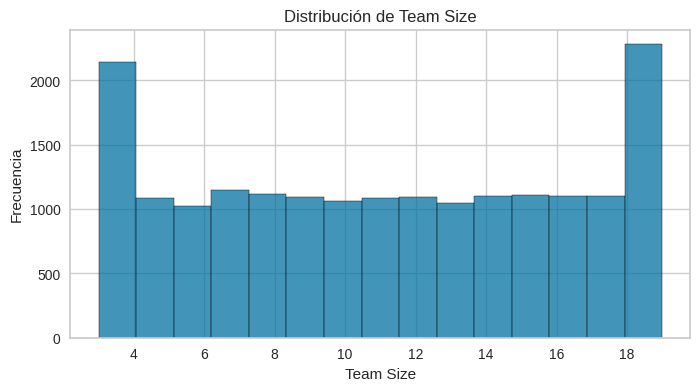

In [ ]:
# Histograma: Team Size
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Team Size"], kde=False, bins=15)
plt.title("Distribución de Team Size")
plt.xlabel("Team Size")
plt.ylabel("Frecuencia")
plt.show()

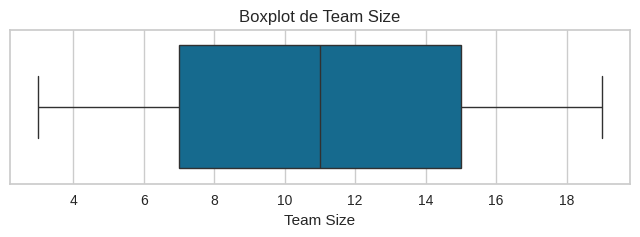

In [ ]:
# Boxplot: Team Size
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Team Size"])
plt.title("Boxplot de Team Size")
plt.xlabel("Team Size")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Team Size"].describe()

,Team Size
count,18590.000000
mean,11.070522
std,4.906268
min,3.000000
25%,7.000000
50%,11.000000
75%,15.000000
max,19.000000


###Recognition Frequency

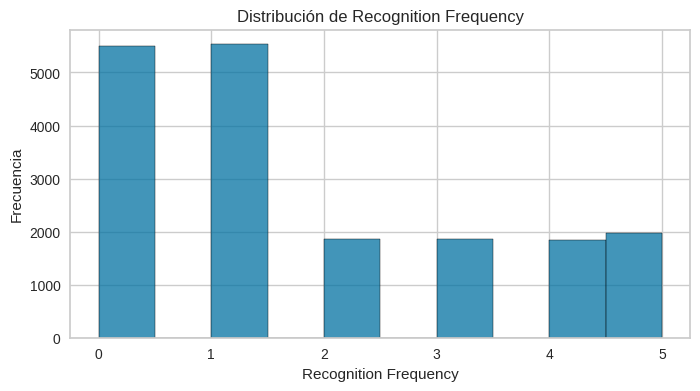

In [ ]:
# Histograma
plt.figure(figsize=(8,4))
sns.histplot(df_prep["Recognition Frequency"], kde=False, bins=10)
plt.title("Distribución de Recognition Frequency")
plt.xlabel("Recognition Frequency")
plt.ylabel("Frecuencia")
plt.show()

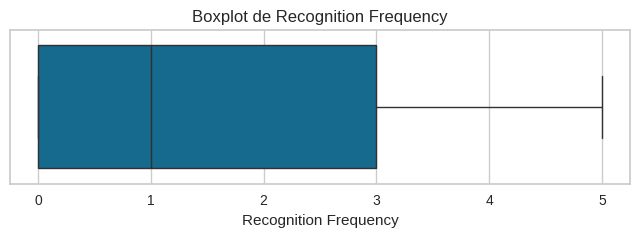

In [ ]:
# Boxplot
plt.figure(figsize=(8,2))
sns.boxplot(x=df_prep["Recognition Frequency"])
plt.title("Boxplot de Recognition Frequency")
plt.xlabel("Recognition Frequency")
plt.show()

In [ ]:
# Estadística descriptiva
df_prep["Recognition Frequency"].describe()

,Recognition Frequency
count,18590.000000
mean,1.729693
std,1.692873
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


##4.2- Análisis de variables categóricas

In [ ]:
categorical_cols = ["Gender", "Company Type", "WFH Setup Available"]

###Gender

In [ ]:
# Conteo de frecuencias
df_prep["Gender"].value_counts()

,count
Gender,
Female,9747
Male,8843


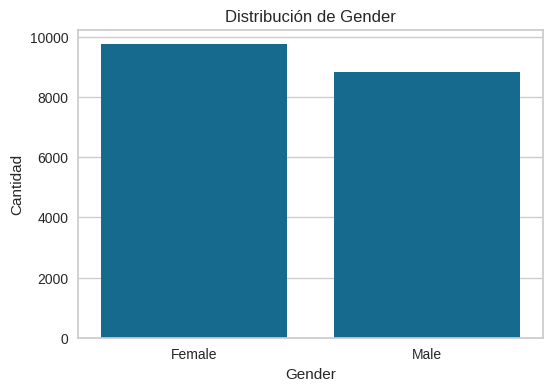

In [ ]:
# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(x=df_prep["Gender"])
plt.title("Distribución de Gender")
plt.xlabel("Gender")
plt.ylabel("Cantidad")
plt.show()

###Company Type

In [ ]:
# Conteo de frecuencias
df_prep["Company Type"].value_counts()

,count
Company Type,
Service,12174
Product,6416


Text(0, 0.5, 'Cantidad')

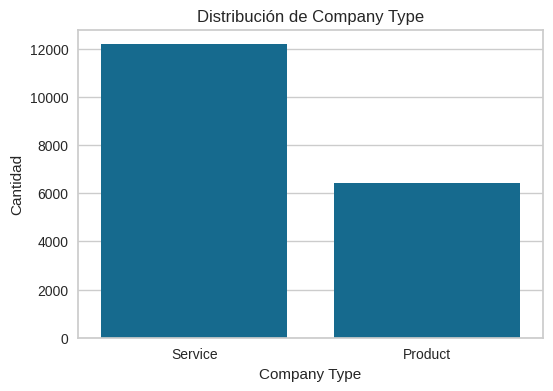

In [ ]:
# Gráfico de barras: Company Type
plt.figure(figsize=(6,4))
sns.countplot(x=df_prep["Company Type"])
plt.title("Distribución de Company Type")
plt.xlabel("Company Type")
plt.ylabel("Cantidad")

### WFH Setup Available

In [ ]:
# Conteo de frecuencias
df_prep["WFH Setup Available"].value_counts()

,count
WFH Setup Available,
Yes,10030
No,8560


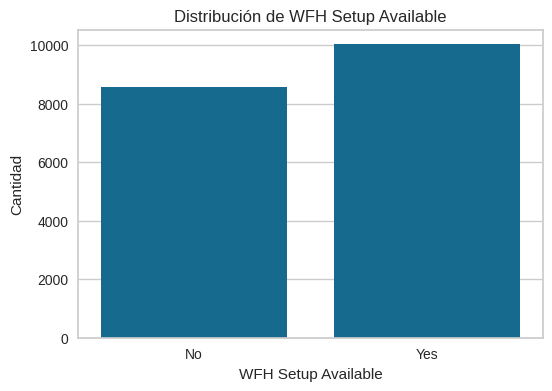

In [ ]:
# Gráfico de barras: WFH Setup Available
plt.figure(figsize=(6,4))
sns.countplot(x=df_prep["WFH Setup Available"])
plt.title("Distribución de WFH Setup Available")
plt.xlabel("WFH Setup Available")
plt.ylabel("Cantidad")
plt.show()


##5- Análsis de variables en conjunto

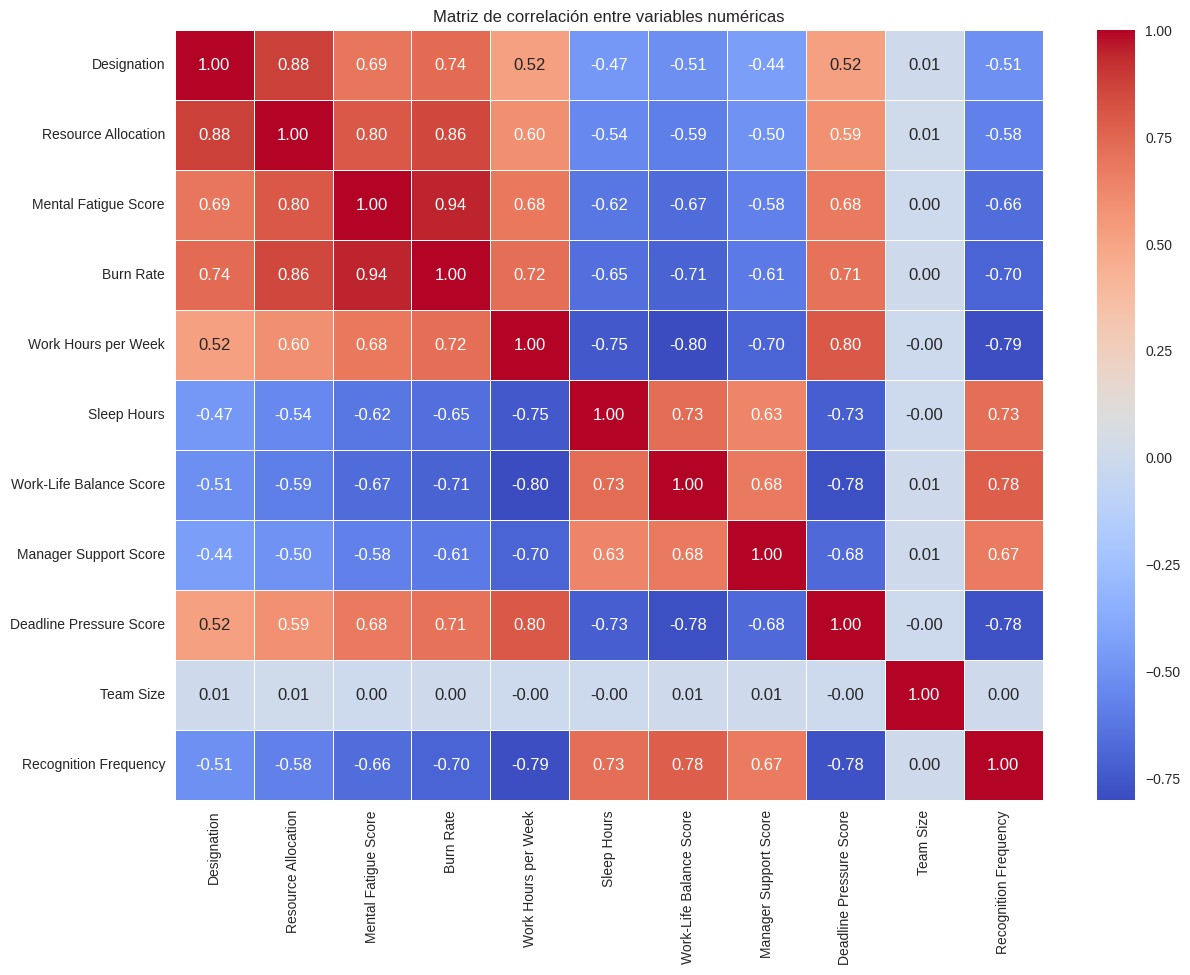

In [ ]:
# Matriz de correlación de todas las variables numéricas
numeric_cols = df_prep.select_dtypes(include=['int64', 'float64']).columns
corr = df_prep[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,       # muestra los valores numéricos
    cmap="coolwarm",  # paleta de colores
    fmt=".2f",        # formato de los números
    linewidths=0.5
)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

In [ ]:
# las correlaciones ordenadas con Burn Rate:
numeric_cols = df_prep.select_dtypes(include=['int64', 'float64']).columns
df_prep[numeric_cols].corr()["Burn Rate"].sort_values(ascending=False)

,Burn Rate
Burn Rate,1.000000
Mental Fatigue Score,0.944389
Resource Allocation,0.855005
Designation,0.736412
Work Hours per Week,0.719273
Deadline Pressure Score,0.708439
Team Size,0.001711
Manager Support Score,-0.607047
Sleep Hours,-0.654239
Recognition Frequency,-0.695483


### 5.1- Visualización de correlaciones numéricas con Burn Rate

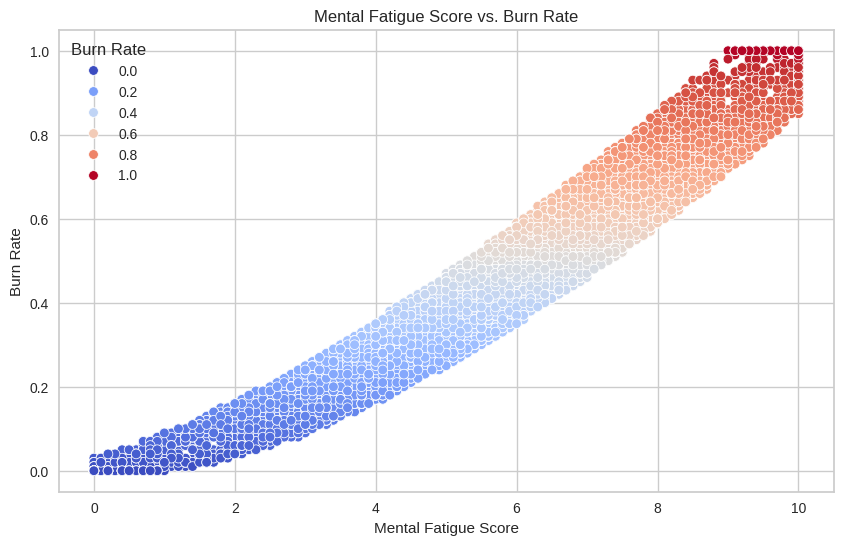

In [ ]:
# Scatter plot - Mental Fatigue Score vs. Burn Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mental Fatigue Score', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='coolwarm')
plt.title('Mental Fatigue Score vs. Burn Rate')
plt.xlabel('Mental Fatigue Score')
plt.ylabel('Burn Rate')
plt.show()

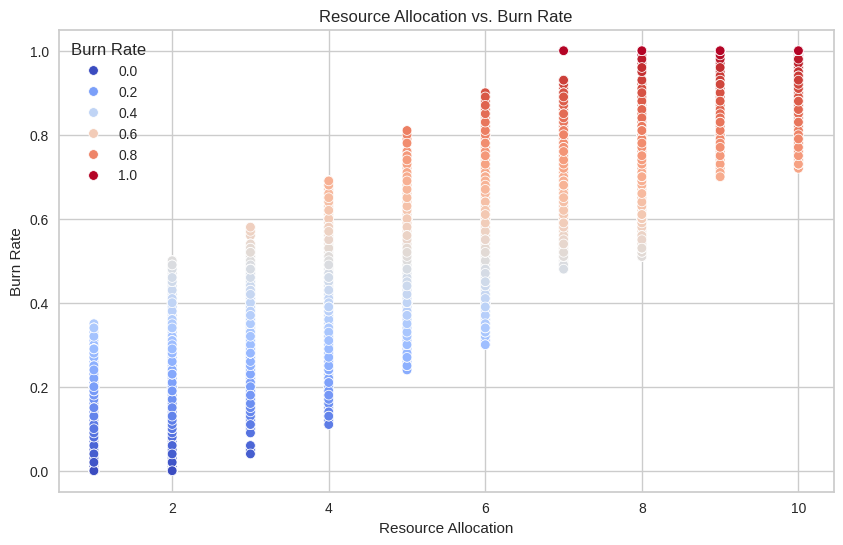

In [ ]:
# Scatter plot - Resource Allocation vs. Burn Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Resource Allocation', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='coolwarm')
plt.title('Resource Allocation vs. Burn Rate')
plt.xlabel('Resource Allocation')
plt.ylabel('Burn Rate')
plt.show()

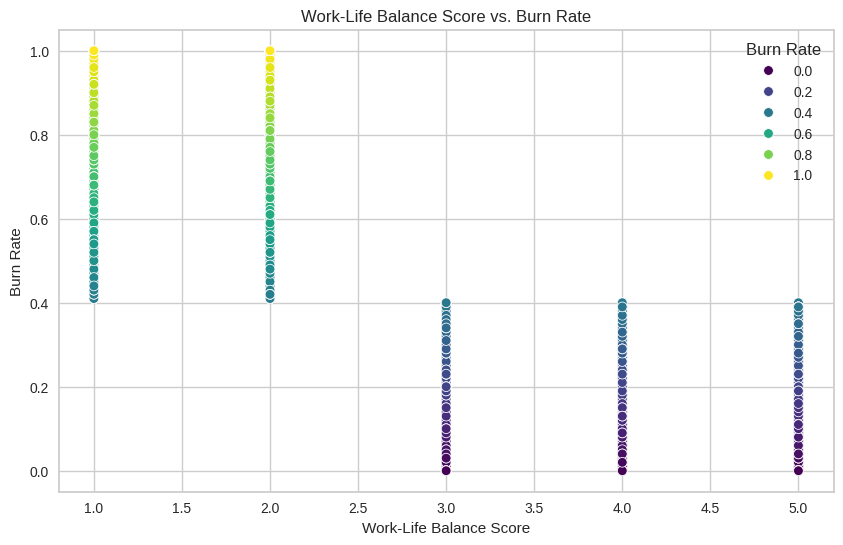

In [ ]:
# Scatter plot - Work-Life Balance Score vs. Burn Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Work-Life Balance Score', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='viridis')
plt.title('Work-Life Balance Score vs. Burn Rate')
plt.xlabel('Work-Life Balance Score')
plt.ylabel('Burn Rate')
plt.show()

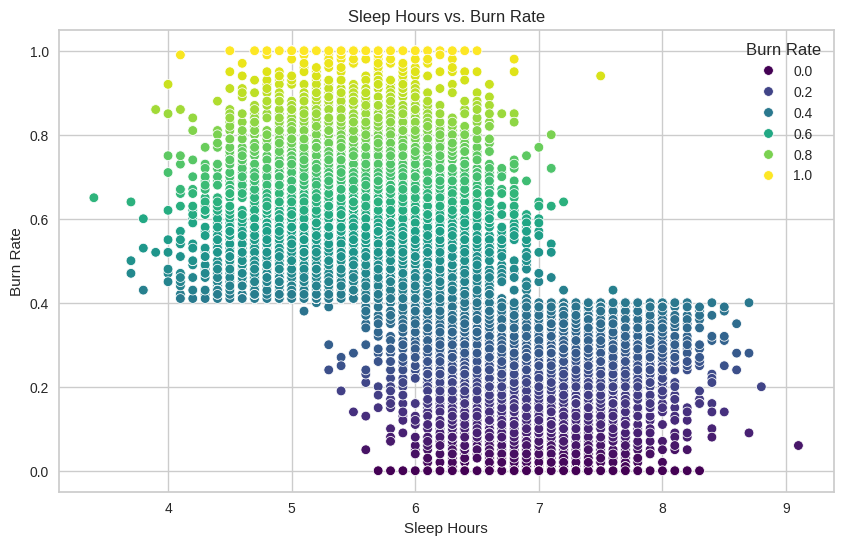

In [ ]:
# Scatter plot - Sleep Hours vs. Burn Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sleep Hours', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='viridis')
plt.title('Sleep Hours vs. Burn Rate')
plt.xlabel('Sleep Hours')
plt.ylabel('Burn Rate')
plt.show()

Text(0, 0.5, 'Burn Rate')

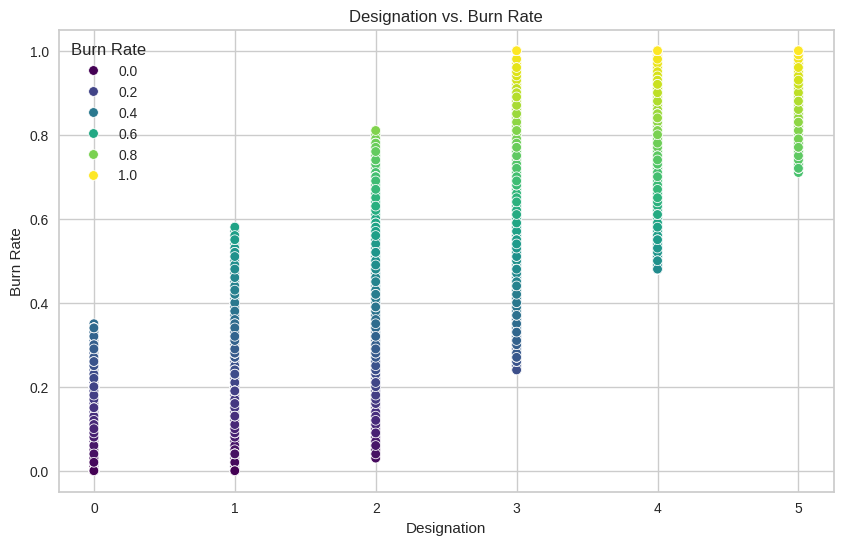

In [ ]:
#scatterplot Designation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Designation', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='viridis')
plt.title('Designation vs. Burn Rate')
plt.xlabel('Designation')
plt.ylabel('Burn Rate')

Text(0, 0.5, 'Burn Rate')

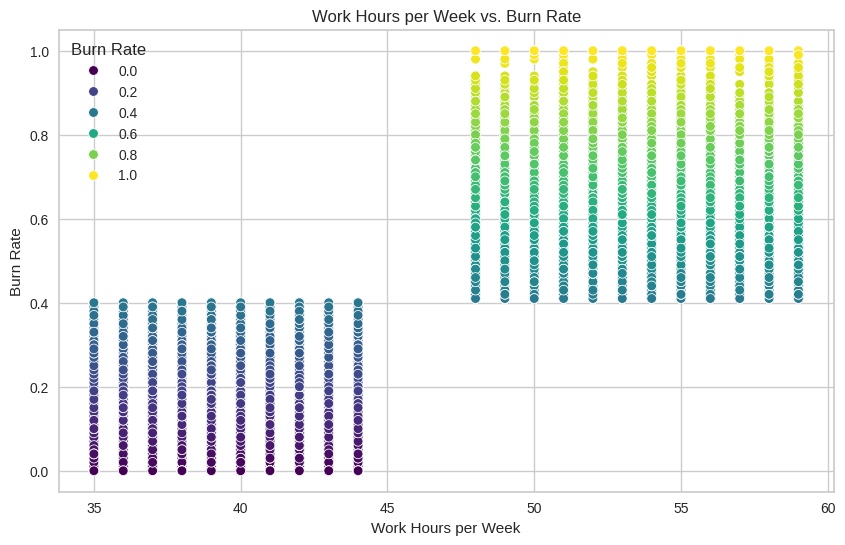

In [ ]:
#Scatterplot Work Hours per Week
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Work Hours per Week', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='viridis')
plt.title('Work Hours per Week vs. Burn Rate')
plt.xlabel('Work Hours per Week')
plt.ylabel('Burn Rate')

Text(0, 0.5, 'Burn Rate')

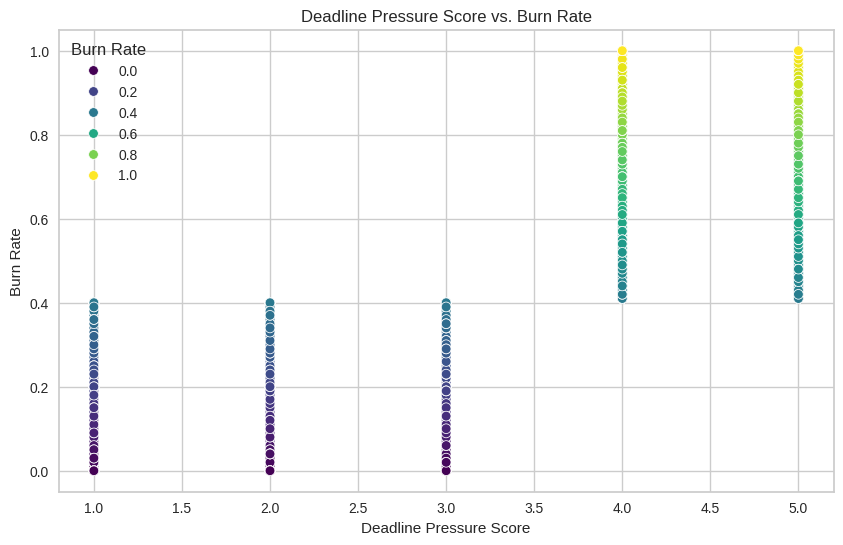

In [ ]:
#Scatterplot Deadline Pressure Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Deadline Pressure Score', y='Burn Rate', data=df_prep, hue='Burn Rate', palette='viridis')
plt.title('Deadline Pressure Score vs. Burn Rate')
plt.xlabel('Deadline Pressure Score')
plt.ylabel('Burn Rate')

/tmp/ipython-input-4156826089.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Team Size', y='Burn Rate', data=df_prep, palette='viridis')


Text(0, 0.5, 'Burn Rate')

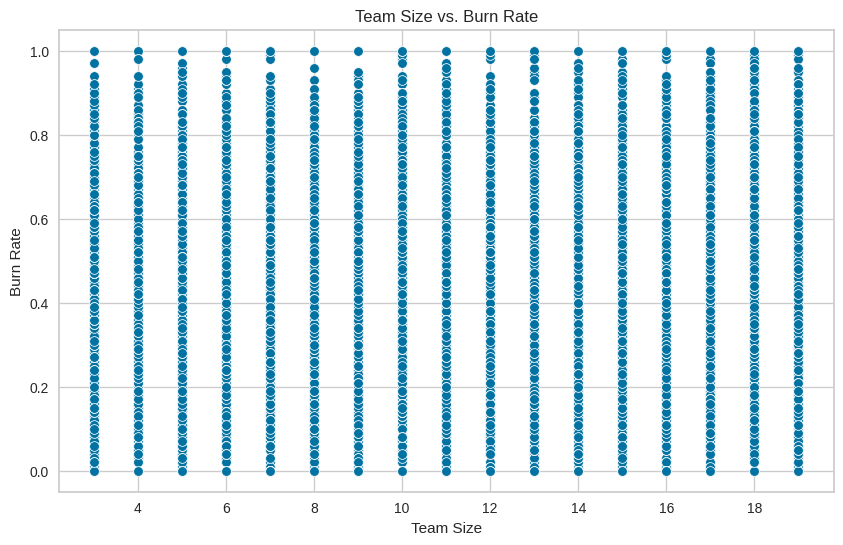

In [ ]:
#Scatterplot Team Size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Team Size', y='Burn Rate', data=df_prep, palette='viridis')
plt.title('Team Size vs. Burn Rate')
plt.xlabel('Team Size')
plt.ylabel('Burn Rate')

/tmp/ipython-input-1111729768.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Manager Support Score', y='Burn Rate', data=df_prep, palette='viridis')


Text(0, 0.5, 'Burn Rate')

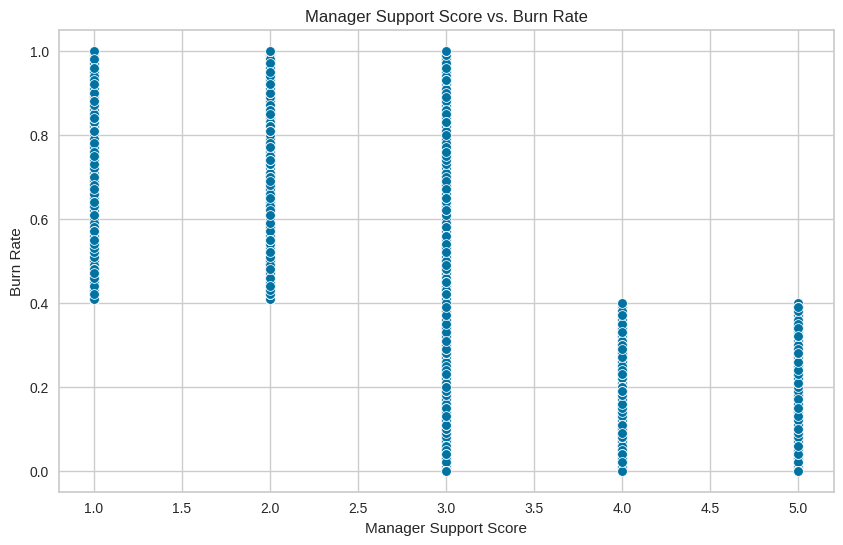

In [ ]:
#Scatterplot Manager Support Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Manager Support Score', y='Burn Rate', data=df_prep, palette='viridis')
plt.title('Manager Support Score vs. Burn Rate')
plt.xlabel('Manager Support Score')
plt.ylabel('Burn Rate')

/tmp/ipython-input-1395248416.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Recognition Frequency', y='Burn Rate', data=df_prep, palette='viridis')


Text(0, 0.5, 'Burn Rate')

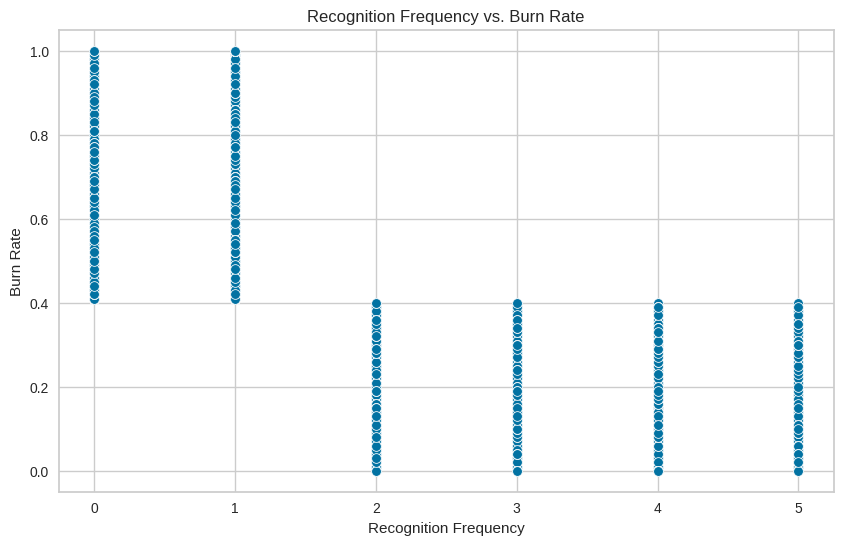

In [ ]:
#Scatterplot Recognition Frequency
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Recognition Frequency', y='Burn Rate', data=df_prep, palette='viridis')
plt.title('Recognition Frequency vs. Burn Rate')
plt.xlabel('Recognition Frequency')
plt.ylabel('Burn Rate')

### 5.2- Análisis de variables categóricas vs. Burn Rate

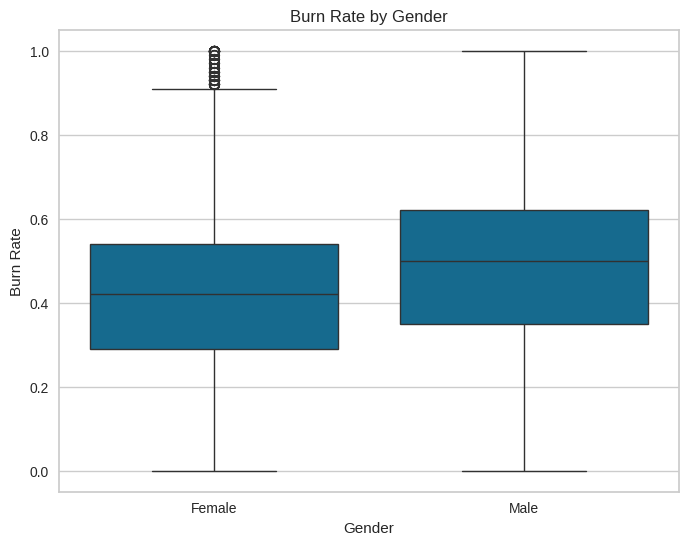

In [ ]:
# Boxplot for Gender vs. Burn Rate
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Burn Rate', data=df_prep)
plt.title('Burn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Burn Rate')
plt.show()

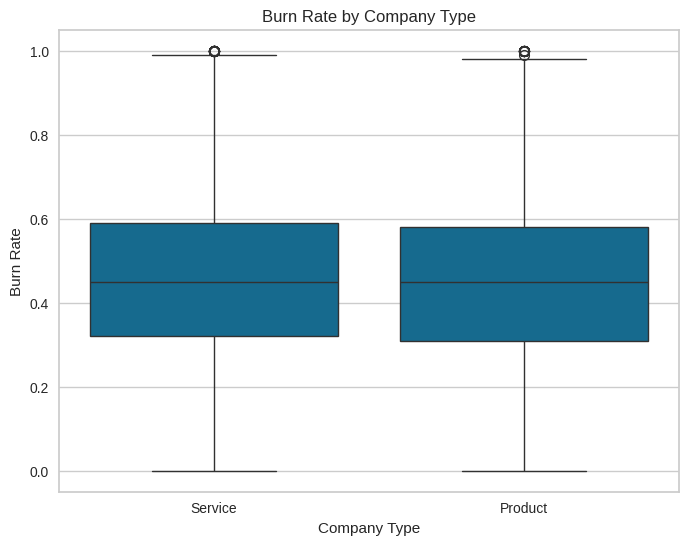

In [ ]:
# Boxplot for Company Type vs. Burn Rate
plt.figure(figsize=(8, 6))
sns.boxplot(x='Company Type', y='Burn Rate', data=df_prep)
plt.title('Burn Rate by Company Type')
plt.xlabel('Company Type')
plt.ylabel('Burn Rate')
plt.show()

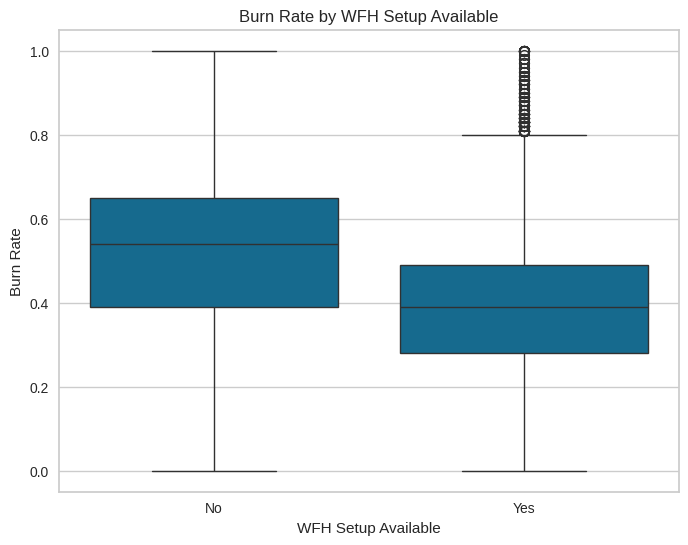

In [ ]:
# Boxplot for WFH Setup Available vs. Burn Rate
plt.figure(figsize=(8, 6))
sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=df_prep)
plt.title('Burn Rate by WFH Setup Available')
plt.xlabel('WFH Setup Available')
plt.ylabel('Burn Rate')
plt.show()

##6- PCA

In [ ]:

# Definición de columnas numéricas para PCA
cols_numeric_pca = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Team Size",
    "Recognition Frequency"
]

In [ ]:
# Dataframe numérico
num_data = df_prep[cols_numeric_pca].copy()

In [ ]:
# Estandarización de variables
X = StandardScaler().fit_transform(num_data)

In [ ]:
# PCA
pca_burnout = PCA ()
X_pca = pca_burnout.fit_transform(X)

# Varianza explicada por componente
explained_variance = pca_burnout.explained_variance_ratio_
print("Varianza explicada por cada componente:")
print(explained_variance)

print("\nVarianza explicada ACUMULADA:")
print(explained_variance.cumsum())

Varianza explicada por cada componente:
[0.6280334  0.10400487 0.09961054 0.03876599 0.02987332 0.02649823
 0.02248054 0.02176941 0.01889968 0.01006404]

Varianza explicada ACUMULADA:
[0.6280334  0.73203826 0.8316488  0.87041479 0.9002881  0.92678633
 0.94926687 0.97103628 0.98993596 1.        ]


In [ ]:
# Cargas
cargas = pd.DataFrame(
    pca_burnout.components_.T,
    columns=[f'PCA{i+1}' for i in range(len(cols_numeric_pca))],
    index=cols_numeric_pca
)

print("\nCargas de las variables en los componentes principales:")
display(cargas)



Cargas de las variables en los componentes principales:


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10
Designation,0.290187,0.573195,-0.182645,-0.067671,-0.104268,-0.470355,0.066967,0.025677,0.000898,-0.558614
Resource Allocation,0.319830,0.509906,-0.157610,-0.028872,-0.034798,-0.036021,-0.004447,-0.006559,0.020400,0.780412
Mental Fatigue Score,0.338627,0.259913,-0.085982,0.059540,0.139449,0.831361,-0.123638,-0.036860,-0.041021,-0.279113
Work Hours per Week,0.355293,-0.197522,0.060963,0.109860,0.148646,-0.048198,0.158460,0.008469,0.876956,-0.017720
Sleep Hours,-0.330892,0.215666,-0.076667,-0.311368,0.854856,-0.057816,0.007108,-0.030432,0.077920,0.000889
Work-Life Balance Score,-0.349641,0.195316,-0.057279,-0.152773,-0.232405,0.140099,-0.212079,0.782459,0.286472,-0.007562
Manager Support Score,-0.312637,0.234335,-0.068641,0.905480,0.137722,-0.034872,0.027237,0.013283,0.040439,-0.001607
Deadline Pressure Score,0.350118,-0.187655,0.061953,0.121693,0.278924,-0.038901,0.519523,0.591383,-0.352184,0.023916
Team Size,-0.000252,0.301809,0.953289,-0.006870,0.006569,0.002235,0.001343,-0.005648,0.001402,-0.004504
Recognition Frequency,-0.347183,0.197476,-0.064980,-0.154703,-0.254511,0.241412,0.799640,-0.186434,0.122633,-0.006012


In [ ]:
autovalores = pca_burnout.explained_variance_
print("Autovalores del PCA:")
print(autovalores)

Autovalores del PCA:
[6.28067184 1.04010461 0.99615895 0.38768072 0.29874922 0.26499653
 0.22481747 0.2177058  0.18900697 0.10064584]


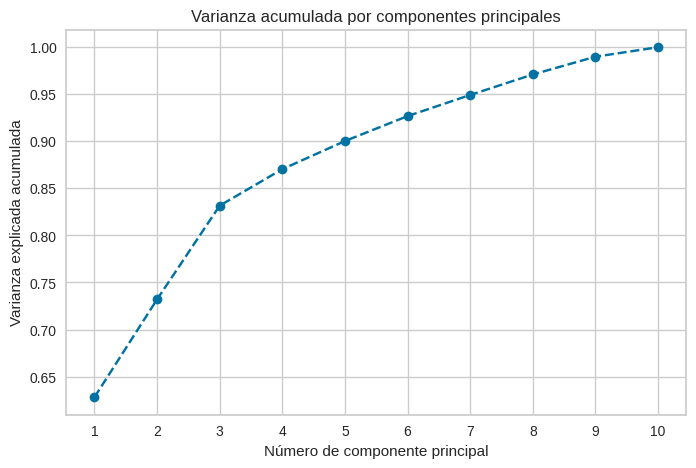

In [ ]:
#Baston partido
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance.cumsum(),
    marker='o',
    linestyle='--'
)
plt.title("Varianza acumulada por componentes principales")
plt.xlabel("Número de componente principal")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

In [ ]:
# Las primeras 3 PCAs

pca_df = pd.DataFrame(X_pca[:, :3], columns=['PCA1', 'PCA2', 'PCA3'])

print("\nPrimeras filas del DF con componentes principales:")
display(pca_df.head())



Primeras filas del DF con componentes principales:


,PCA1,PCA2,PCA3
0,-2.581899,0.718546,0.814449
1,-2.969095,-0.134646,-0.192861
2,-2.689905,-1.035388,0.733909
3,2.120790,0.870261,1.214720
4,-2.603144,0.637860,-0.643799


In [ ]:
!pip install adjustText
from adjustText import adjust_text

##7 Clustering

In [ ]:
pca_df = pd.DataFrame(X_pca[:, :3], columns=['PCA1', 'PCA2', 'PCA3'])


In [ ]:
# Usamos solo las primeras 3 componentes principales
X_cluster = pca_df[["PCA1", "PCA2", "PCA3"]].values

k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

pca_df["Cluster"] = kmeans.fit_predict(X_cluster)

In [ ]:
df_prep = df_prep.reset_index(drop=True)
pca_df = pca_df.reset_index(drop=True)

df_clusters = df_prep.copy()
df_clusters["Cluster"] = pca_df["Cluster"]


In [ ]:
vars_interes = [
    "Burn Rate",
    "Mental Fatigue Score",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Resource Allocation",
    "Designation",
    "Recognition Frequency"
]

perfiles_clusters = df_clusters.groupby("Cluster")[vars_interes].mean()
perfiles_clusters


,Burn Rate,Mental Fatigue Score,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Resource Allocation,Designation,Recognition Frequency
Cluster,,,,,,,,,,
0,0.262186,3.974491,39.496560,6.994350,4.003175,3.992458,1.988092,2.848770,1.384493,3.522625
1,0.680162,7.756116,53.555532,5.519809,1.489283,2.018619,4.504438,7.112362,3.548820,0.487984
2,0.512657,6.345922,53.445345,5.493170,1.510525,1.993451,4.491346,4.525495,2.129892,0.510993


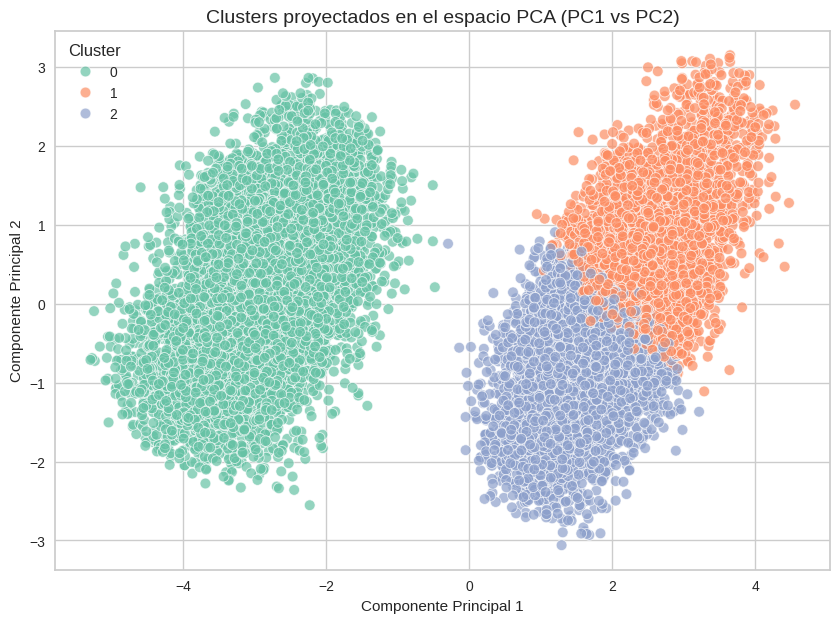

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_df["PCA1"],
    y=pca_df["PCA2"],
    hue=pca_df["Cluster"],
    palette="Set2",
    alpha=0.7,
    s=60
)

plt.title("Clusters proyectados en el espacio PCA (PC1 vs PC2)", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()


## 8- ANOVA

In [ ]:
# 8 - ANOVA por clusters

# Variables numéricas a analizar (incluyo Burn Rate)
vars_anova = [
    "Burn Rate",
    "Mental Fatigue Score",
    "Work Hours per Week",
    "Sleep Hours",
    "Work-Life Balance Score",
    "Manager Support Score",
    "Deadline Pressure Score",
    "Resource Allocation",
    "Team Size",
    "Recognition Frequency",
    "Designation"
]

# Creamos una copia solo con lo que necesitamos
data_anova = df_clusters[vars_anova + ["Cluster"]].copy()

resultados_anova = []

for var in vars_anova:
    # armamos los grupos según el cluster
    grupos = [data_anova.loc[data_anova["Cluster"] == g, var]
              for g in sorted(data_anova["Cluster"].unique())]

    f_stat, p_val = f_oneway(*grupos)
    resultados_anova.append({"Variable": var, "F": f_stat, "p_value": p_val})

# Pasamos a DataFrame y lo ordenamos por p-value
tabla_anova = pd.DataFrame(resultados_anova).sort_values("p_value")
tabla_anova


,Variable,F,p_value
0,Burn Rate,26058.986927,0.000000
1,Mental Fatigue Score,17391.874933,0.000000
2,Work Hours per Week,41681.716251,0.000000
3,Sleep Hours,19846.340021,0.000000
4,Work-Life Balance Score,33760.039543,0.000000
5,Manager Support Score,13266.460236,0.000000
6,Deadline Pressure Score,33632.824850,0.000000
7,Resource Allocation,18926.244180,0.000000
9,Recognition Frequency,30859.162244,0.000000
10,Designation,12004.581559,0.000000


/tmp/ipython-input-2021530889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y="Burn Rate", data=df_clusters, palette="Set2")


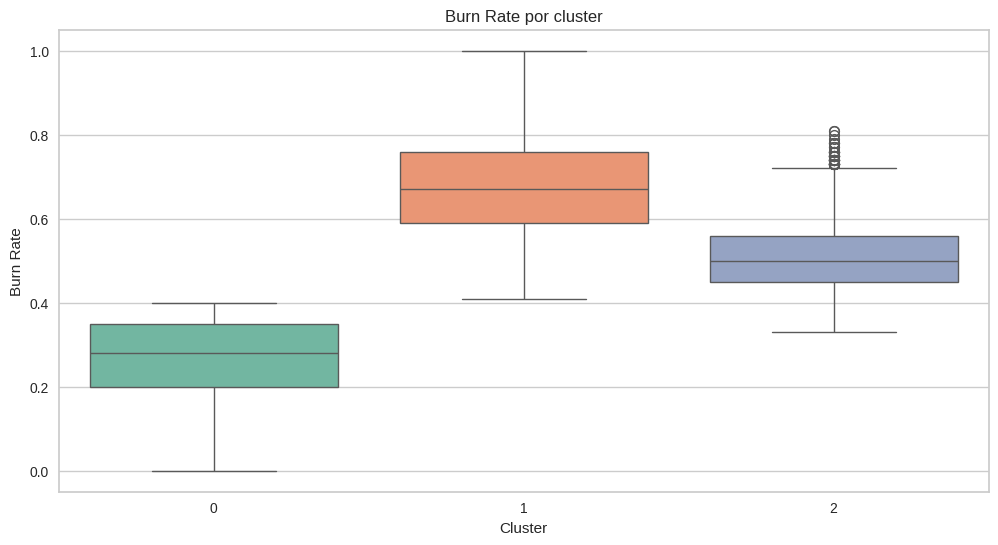

/tmp/ipython-input-2021530889.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y="Mental Fatigue Score", data=df_clusters, palette="Set2")


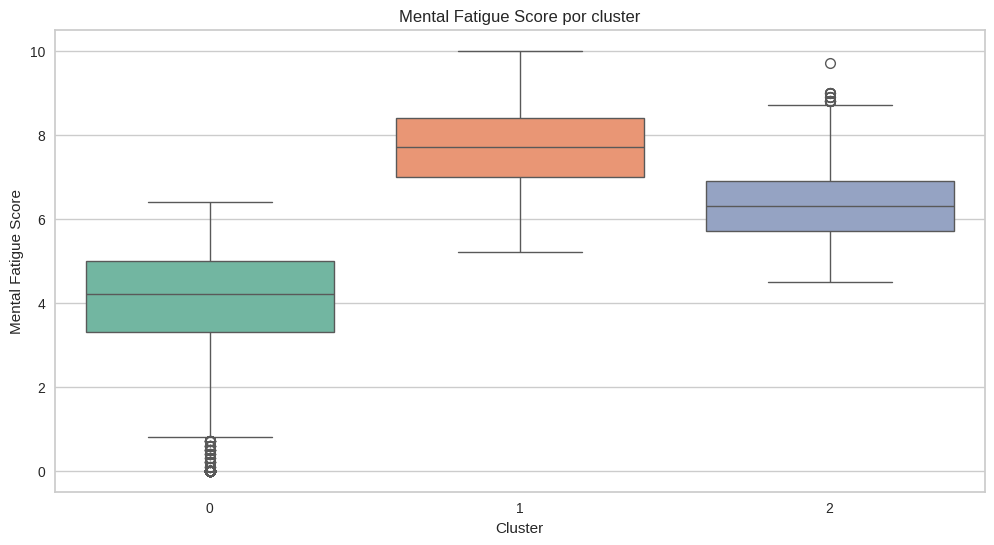

/tmp/ipython-input-2021530889.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y="Work-Life Balance Score", data=df_clusters, palette="Set2")


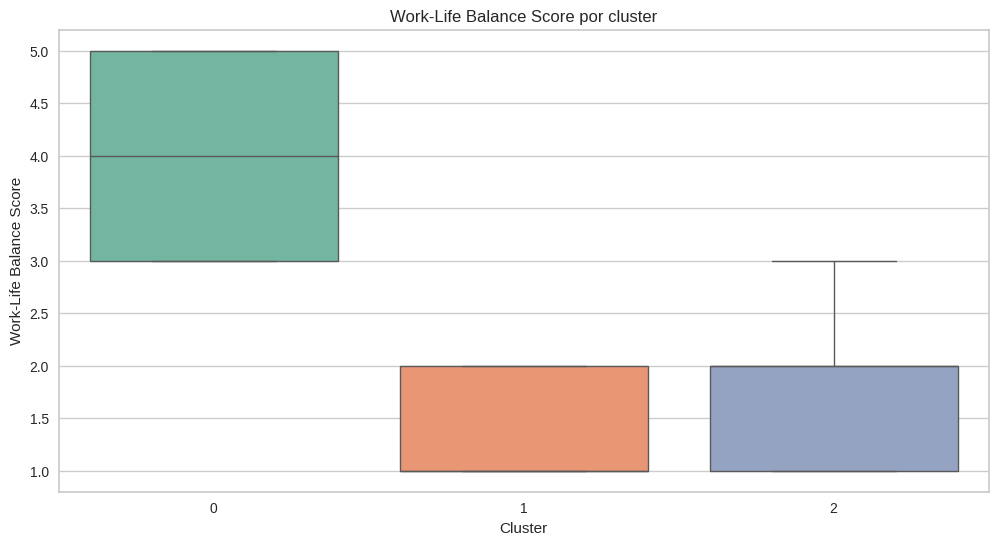

/tmp/ipython-input-2021530889.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y="Work Hours per Week", data=df_clusters, palette="Set2")


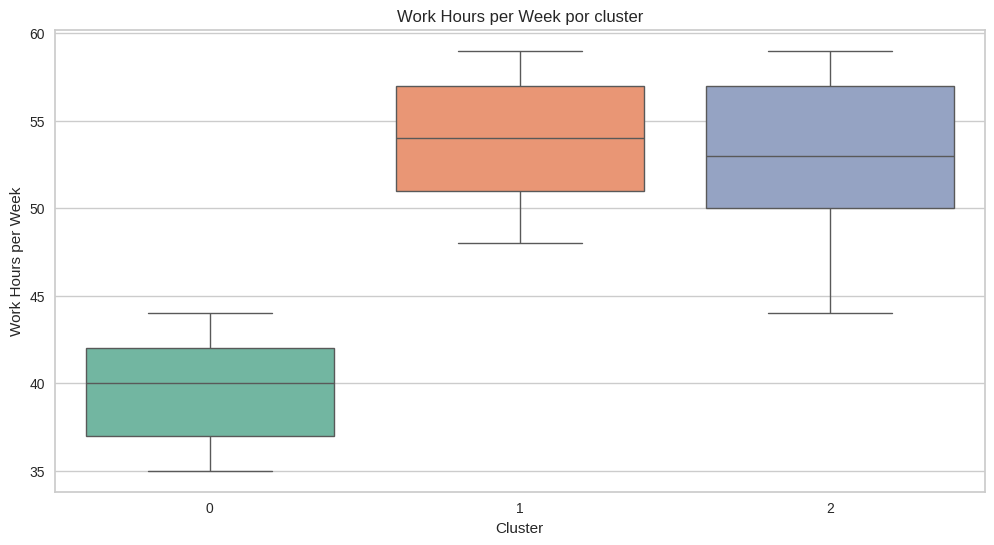

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Cluster", y="Burn Rate", data=df_clusters, palette="Set2")
plt.title("Burn Rate por cluster")
plt.xlabel("Cluster")
plt.ylabel("Burn Rate")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Cluster", y="Mental Fatigue Score", data=df_clusters, palette="Set2")
plt.title("Mental Fatigue Score por cluster")
plt.xlabel("Cluster")
plt.ylabel("Mental Fatigue Score")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Cluster", y="Work-Life Balance Score", data=df_clusters, palette="Set2")
plt.title("Work-Life Balance Score por cluster")
plt.xlabel("Cluster")
plt.ylabel("Work-Life Balance Score")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x="Cluster", y="Work Hours per Week", data=df_clusters, palette="Set2")
plt.title("Work Hours per Week por cluster")
plt.xlabel("Cluster")
plt.ylabel("Work Hours per Week")
plt.show()


##9- MANOVA

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# Renombrar columnas con espacios
df_manova = df_clusters.rename(columns={
    "Burn Rate": "Burn_Rate",
    "Mental Fatigue Score": "Mental_Fatigue_Score",
    "Work Hours per Week": "Work_Hours_Per_Week",
    "Sleep Hours": "Sleep_Hours",
    "Work-Life Balance Score": "Work_Life_Balance_Score",
    "Manager Support Score": "Manager_Support_Score",
    "Deadline Pressure Score": "Deadline_Pressure_Score",
    "Resource Allocation": "Resource_Allocation",
    "Recognition Frequency": "Recognition_Frequency",
    "Designation": "Designation",
    "Team Size": "Team_Size"
})


In [ ]:
formula = (
    "Burn_Rate + Mental_Fatigue_Score + Work_Hours_Per_Week + Sleep_Hours + "
    "Work_Life_Balance_Score + Manager_Support_Score + Deadline_Pressure_Score + "
    "Resource_Allocation + Recognition_Frequency + Designation + Team_Size ~ Cluster"
)


In [ ]:
manova = MANOVA.from_formula(formula, data=df_manova)
print(manova.mv_test())


                      Multivariate linear model
                                                                      
----------------------------------------------------------------------
       Intercept         Value    Num DF   Den DF     F Value   Pr > F
----------------------------------------------------------------------
          Wilks' lambda   0.0048 11.0000 18578.0000 352359.0198 0.0000
         Pillai's trace   0.9952 11.0000 18578.0000 352359.0198 0.0000
 Hotelling-Lawley trace 208.6311 11.0000 18578.0000 352359.0198 0.0000
    Roy's greatest root 208.6311 11.0000 18578.0000 352359.0198 0.0000
----------------------------------------------------------------------
                                                                      
----------------------------------------------------------------------
            Cluster         Value   Num DF   Den DF    F Value  Pr > F
----------------------------------------------------------------------
              Wilks' lambda 0

##10- Random Forest Regressor

In [ ]:
# dataset de modelado
df_model = df_prep.copy()

In [ ]:
# One-hot encoding para las variables categóricas
cat_cols = ["Gender", "Company Type", "WFH Setup Available"]

df_model_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

In [ ]:
df_model_enc.head()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Work Hours per Week,Sleep Hours,Work-Life Balance Score,Manager Support Score,Deadline Pressure Score,Team Size,Recognition Frequency,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,2,3.0,3.8,0.16,35,7.5,3,3,1,16,2,False,True,False
1,1,2.0,5.0,0.36,41,7.1,5,3,3,10,5,True,True,True
2,1,1.0,2.6,0.20,43,6.7,3,3,1,13,2,True,True,True
3,3,7.0,6.9,0.52,51,5.2,1,3,4,18,0,False,True,False
4,2,4.0,3.6,0.29,41,7.0,4,4,3,9,5,True,False,True


In [ ]:
# Variable objetivo
y = df_model_enc["Burn Rate"]

# Variables predictoras: todas menos Burn Rate
X = df_model_enc.drop(columns=["Burn Rate"])

X.shape, y.shape

((18590, 13), (18590,))

In [ ]:
# División en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((14872, 13), (3718, 13))

In [ ]:
# Entrenamiento del Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicciones sobre el set de prueba
y_pred = rf.predict(X_test)

# Métricas de desempeño
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE (test): {rmse:.4f}")


R² (test): 0.9390
RMSE (test): 0.0484


In [ ]:
rmse_train = np.sqrt(mean_squared_error(y_train, rf.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred))

print("RMSE train:", rmse_train)
print("RMSE test :", rmse_test)



RMSE train: 0.01803407025581391
RMSE test : 0.04840314014455269


In [ ]:
# Cross-validation usando MSE negativo
mse_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Convertir a RMSE positivo
rmse_scores = np.sqrt(-mse_scores)

print("RMSE por fold:", rmse_scores)
print("RMSE promedio (CV 5-fold):", rmse_scores.mean())
print("Desvío estándar del RMSE (CV):", rmse_scores.std())


RMSE por fold: [0.04902041 0.04924018 0.04866301 0.04812918 0.04899851]
RMSE promedio (CV 5-fold): 0.048810258672358095
Desvío estándar del RMSE (CV): 0.0003872921281117195


In [ ]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values("Importancia", ascending=False)
display(importancias.head(15))


,Variable,Importancia
2,Mental Fatigue Score,0.286609
3,Work Hours per Week,0.237520
7,Deadline Pressure Score,0.203617
9,Recognition Frequency,0.131862
5,Work-Life Balance Score,0.078707
1,Resource Allocation,0.025471
4,Sleep Hours,0.010932
8,Team Size,0.010263
0,Designation,0.004563
6,Manager Support Score,0.003522


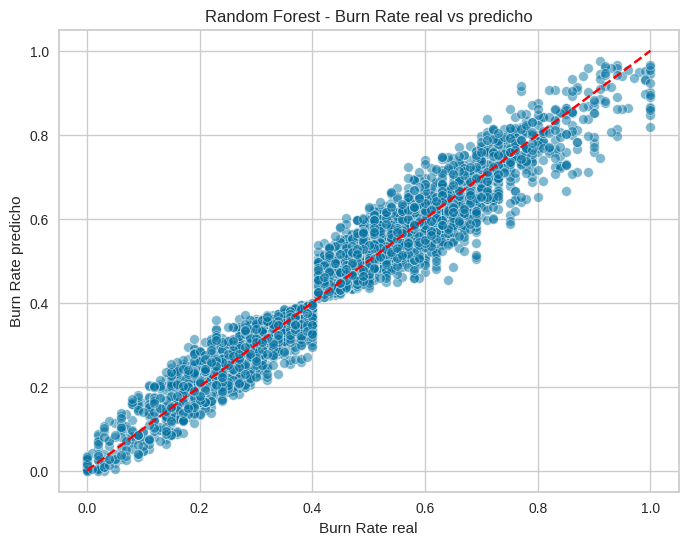

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
          [y_test.min(), y_test.max()],
          linestyle="--", color="red")
plt.xlabel("Burn Rate real")
plt.ylabel("Burn Rate predicho")
plt.title("Random Forest - Burn Rate real vs predicho")
plt.show()

#